# Computation Graph Visualizations

- **Forward graph**: `torchview.draw_graph()` - shows model architecture
- **Backward graph**: `torchviz.make_dot()` - shows autograd graph for backpropagation

In [1]:
import torch
import torch.nn as nn
from torchview import draw_graph
from torchviz import make_dot
import os

os.makedirs('images', exist_ok=True)

## 0. Simple Example: Chaining Operations

This is the example from the slides: `c = a * b`, `e = c + d`, `f = relu(e)`

In [2]:
# Simple chaining: c = a * b, e = c + d, f = relu(e)
a = torch.tensor([3.0], requires_grad=True)
b = torch.tensor([2.0], requires_grad=True)
d = torch.tensor([1.0], requires_grad=True)

c = a * b      # c = 6
e = c + d      # e = 7
f = torch.relu(e)  # f = 7 (relu passes through positive values)

print("Forward pass:")
print(f"  a = {a.item()}, b = {b.item()}, d = {d.item()}")
print(f"  c = a * b = {c.item()}")
print(f"  e = c + d = {e.item()}")
print(f"  f = relu(e) = {f.item()}")
print()

# Backward pass
f.backward()

print("Backward pass (gradients):")
print(f"  df/da = {a.grad.item()}")  # b = 2
print(f"  df/db = {b.grad.item()}")  # a = 3
print(f"  df/dd = {d.grad.item()}")  # 1

Forward pass:
  a = 3.0, b = 2.0, d = 1.0
  c = a * b = 6.0
  e = c + d = 7.0
  f = relu(e) = 7.0

Backward pass (gradients):
  df/da = 2.0
  df/db = 3.0
  df/dd = 1.0


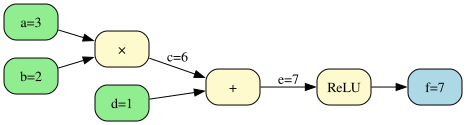

In [3]:
# Clean graphviz version of simple chain
from graphviz import Digraph

dot = Digraph(format='png')
dot.attr(rankdir='LR', size='12,4')
dot.attr('node', shape='box', style='rounded,filled', fontsize='14')

# Inputs (green)
dot.attr('node', fillcolor='#90EE90')
dot.node('a', 'a=3')
dot.node('b', 'b=2')
dot.node('d', 'd=1')

# Operations (yellow)
dot.attr('node', fillcolor='#FFFACD')
dot.node('mul', '×')
dot.node('add', '+')
dot.node('relu', 'ReLU')

# Output (blue)
dot.attr('node', fillcolor='#ADD8E6')
dot.node('f', 'f=7')

# Edges with intermediate values
dot.edge('a', 'mul')
dot.edge('b', 'mul')
dot.edge('mul', 'add', label='c=6')
dot.edge('d', 'add')
dot.edge('add', 'relu', label='e=7')
dot.edge('relu', 'f')

dot.render('images/simple_chain_clean', cleanup=True)
dot

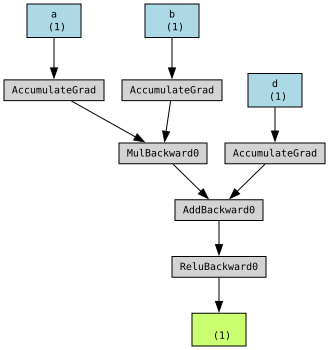

In [5]:
# Visualize with torchviz (backward graph)
a = torch.tensor([3.0], requires_grad=True)
b = torch.tensor([2.0], requires_grad=True)
d = torch.tensor([1.0], requires_grad=True)

c = a * b
e = c + d
f = torch.relu(e)

dot = make_dot(f, params={'a': a, 'b': b, 'd': d})
dot.attr(rankdir='TB')
dot.render('images/simple_chain_backward', format='png', cleanup=True)
dot

In [8]:
# Inspect the grad_fn chain
a = torch.tensor([3.0], requires_grad=True)
b = torch.tensor([2.0], requires_grad=True)
d = torch.tensor([1.0], requires_grad=True)

c = a * b
e = c + d
f = torch.relu(e)

print("Each tensor knows what created it:")
print(f"  f.grad_fn = {f.grad_fn}")
print(f"  e.grad_fn = {e.grad_fn}")
print(f"  c.grad_fn = {c.grad_fn}")
print(f"  a.grad_fn = {a.grad_fn}  (None - it's a leaf)")
print()

# Walk the chain
print("Walking the backward chain from e:")

def print_grad_fn(x, tensors=None, depth=0):                                                    
    fn = x.grad_fn if hasattr(x, 'grad_fn') else x                                                                                                                                          
    if fn is None:                                                                              
        return                                                                                                                                                                              
    indent = "  " * depth                                                                       
    name = None                                                                                                                                                                            
    if tensors:                                                                                 
        # For leaf tensors: AccumulateGrad has .variable pointing to the tensor                 
        if type(fn).__name__ == 'AccumulateGrad':                                               
            for var_name, tensor in tensors.items():                                            
                if fn.variable is tensor:                                                       
                    name = var_name                                                             
                    break                                                                       
        else:                                                                                   
            # For intermediate tensors: match by grad_fn                                        
            for var_name, tensor in tensors.items():                                            
                if tensor.grad_fn is fn:                                                        
                    name = var_name                                                             
                    break                                                                                                                                                                
    prefix = f"{name}: " if name else ""                                                        
    print(f"{indent}{prefix}{fn}")
    for next_fn, _ in fn.next_functions:                                                        
        print_grad_fn(next_fn, tensors=tensors, depth=depth + 1)                                
                                                                                                  
# Pass all tensors                                                                              
print_grad_fn(f, tensors={'a': a, 'b': b, 'c': c, 'd': d, 'e': e, 'f': f})  

Each tensor knows what created it:
  f.grad_fn = <ReluBackward0 object at 0x12fab0a90>
  e.grad_fn = <AddBackward0 object at 0x12fab0a90>
  c.grad_fn = <MulBackward0 object at 0x12fab0a90>
  a.grad_fn = None  (None - it's a leaf)

Walking the backward chain from e:
f: <ReluBackward0 object at 0x12fab0a90>
  e: <AddBackward0 object at 0x12fc27730>
    c: <MulBackward0 object at 0x12fc27b50>
      a: <AccumulateGrad object at 0x12fc27ac0>
      b: <AccumulateGrad object at 0x12fc36650>
    d: <AccumulateGrad object at 0x12fc259f0>


## 1. Logistic Regression

In [ ]:
class LogisticRegression(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)
    
    def forward(self, x):
        return torch.sigmoid(self.linear(x))

model = LogisticRegression(4)

In [ ]:
from graphviz import Digraph

# Logistic Regression - Clean Forward Graph
dot = Digraph(format='png')
dot.attr(rankdir='LR', size='10,3')
dot.attr('node', shape='box', style='rounded,filled', fontsize='14')

dot.attr('node', fillcolor='#90EE90')  # green for inputs
dot.node('x', 'x')
dot.node('w', 'w')
dot.node('b', 'b')

dot.attr('node', fillcolor='#FFFACD')  # yellow for operations
dot.node('matmul', 'wᵀx')
dot.node('add', '+')
dot.node('sigmoid', 'σ')

dot.attr('node', fillcolor='#ADD8E6')  # blue for output
dot.node('yhat', 'ŷ')

dot.edge('x', 'matmul')
dot.edge('w', 'matmul')
dot.edge('matmul', 'add', label='z')
dot.edge('b', 'add')
dot.edge('add', 'sigmoid', label='a')
dot.edge('sigmoid', 'yhat')

dot.render('images/logistic_clean', cleanup=True)
dot

In [ ]:
# Forward graph
graph = draw_graph(model, input_size=(1, 4), save_graph=True, 
                   filename='images/logistic_forward')
graph.visual_graph

In [ ]:
# Backward graph
x = torch.randn(1, 4)
y = torch.tensor([[1.0]])
y_hat = model(x)
loss = nn.functional.binary_cross_entropy(y_hat, y)

dot = make_dot(loss, params=dict(model.named_parameters()))
dot.attr(rankdir='TB')
dot.render('images/logistic_backward', format='png', cleanup=True)
dot

## 2. MLP (2 layers)

In [ ]:
model = nn.Sequential(
    nn.Linear(4, 8),
    nn.ReLU(),
    nn.Linear(8, 2)
)

In [ ]:
# Forward graph
graph = draw_graph(model, input_size=(1, 4), save_graph=True,
                   filename='images/mlp_forward')
graph.visual_graph

In [ ]:
# Backward graph
x = torch.randn(1, 4)
loss = model(x).sum()

dot = make_dot(loss, params=dict(model.named_parameters()))
dot.attr(rankdir='TB')
dot.render('images/mlp_backward', format='png', cleanup=True)
dot

## 3. RNN (Manual Unroll - 3 timesteps)

In [ ]:
class SimpleRNNCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.Wx = nn.Linear(input_size, hidden_size, bias=False)
        self.Wh = nn.Linear(hidden_size, hidden_size, bias=False)
    
    def forward(self, x, h):
        return torch.tanh(self.Wx(x) + self.Wh(h))

class UnrolledRNN(nn.Module):
    def __init__(self, input_size, hidden_size, seq_len=3):
        super().__init__()
        self.cell = SimpleRNNCell(input_size, hidden_size)
        self.hidden_size = hidden_size
        self.seq_len = seq_len
    
    def forward(self, x):
        # x: (batch, seq_len, input_size)
        batch_size = x.size(0)
        h = torch.zeros(batch_size, self.hidden_size)
        for t in range(self.seq_len):
            h = self.cell(x[:, t, :], h)
        return h

model = UnrolledRNN(input_size=4, hidden_size=3, seq_len=3)

In [ ]:
# RNN Unrolled - Clean Graph
dot = Digraph(format='png')
dot.attr(rankdir='LR', size='14,5')
dot.attr('node', shape='box', style='rounded,filled', fontsize='12')

# Hidden states (blue)
dot.attr('node', fillcolor='#ADD8E6')
dot.node('h0', 'h₀')
dot.node('h1', 'h₁')
dot.node('h2', 'h₂')
dot.node('h3', 'h₃')

# Inputs (green)
dot.attr('node', fillcolor='#90EE90')
dot.node('x1', 'x₁')
dot.node('x2', 'x₂')
dot.node('x3', 'x₃')

# RNN cells (yellow)
dot.attr('node', fillcolor='#FFFACD')
dot.node('rnn1', 'tanh(Wₓx + Wₕh)')
dot.node('rnn2', 'tanh(Wₓx + Wₕh)')
dot.node('rnn3', 'tanh(Wₓx + Wₕh)')

# Connections
dot.edge('h0', 'rnn1')
dot.edge('x1', 'rnn1')
dot.edge('rnn1', 'h1')

dot.edge('h1', 'rnn2')
dot.edge('x2', 'rnn2')
dot.edge('rnn2', 'h2')

dot.edge('h2', 'rnn3')
dot.edge('x3', 'rnn3')
dot.edge('rnn3', 'h3')

dot.render('images/rnn_clean', cleanup=True)
dot

In [ ]:
# Forward graph
graph = draw_graph(model, input_size=(1, 3, 4), save_graph=True,
                   filename='images/rnn_forward')
graph.visual_graph

In [ ]:
# Backward graph
x = torch.randn(1, 3, 4)
loss = model(x).sum()

dot = make_dot(loss, params=dict(model.named_parameters()))
dot.attr(rankdir='TB')
dot.render('images/rnn_backward', format='png', cleanup=True)
dot

In [ ]:
# RNN Unrolled - Clean Backward Graph (BPTT)
# Shows gradient flow from loss back through time
dot = Digraph(format='png')
dot.attr(rankdir='RL', size='14,5')  # Right to left for backward
dot.attr('node', shape='box', style='rounded,filled', fontsize='12')

# Loss at the end (red)
dot.attr('node', fillcolor='#FFB6C1')
dot.node('loss', 'Loss')
dot.node('dL', '∂L/∂h₃ = 1')

# Gradient nodes (orange for gradients)
dot.attr('node', fillcolor='#FFDAB9')
dot.node('dh3', '∂L/∂h₂')
dot.node('dh2', '∂L/∂h₁')
dot.node('dh1', '∂L/∂h₀')

# Backward through tanh (yellow)
dot.attr('node', fillcolor='#FFFACD')
dot.node('tanh3_bw', 'TanhBackward\n× (1-tanh²)')
dot.node('tanh2_bw', 'TanhBackward\n× (1-tanh²)')
dot.node('tanh1_bw', 'TanhBackward\n× (1-tanh²)')

# Weight gradients accumulate (blue)
dot.attr('node', fillcolor='#ADD8E6')
dot.node('dWh', '∂L/∂Wₕ\n(accumulated)')
dot.node('dWx', '∂L/∂Wₓ\n(accumulated)')

# Flow
dot.edge('loss', 'dL')
dot.edge('dL', 'tanh3_bw')
dot.edge('tanh3_bw', 'dh3', label='× Wₕᵀ')
dot.edge('tanh3_bw', 'dWh', style='dashed')
dot.edge('tanh3_bw', 'dWx', style='dashed')

dot.edge('dh3', 'tanh2_bw')
dot.edge('tanh2_bw', 'dh2', label='× Wₕᵀ')
dot.edge('tanh2_bw', 'dWh', style='dashed')
dot.edge('tanh2_bw', 'dWx', style='dashed')

dot.edge('dh2', 'tanh1_bw')
dot.edge('tanh1_bw', 'dh1', label='× Wₕᵀ')
dot.edge('tanh1_bw', 'dWh', style='dashed')
dot.edge('tanh1_bw', 'dWx', style='dashed')

dot.render('images/rnn_backward_clean', cleanup=True)
dot

## 4. RNN with nn.RNN

In [ ]:
class RNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(input_size=4, hidden_size=3, num_layers=1, batch_first=True)
    
    def forward(self, x):
        output, hn = self.rnn(x)
        return output

model = RNNModel()

In [ ]:
# Forward graph
graph = draw_graph(model, input_size=(1, 5, 4), save_graph=True,
                   filename='images/rnn_builtin_forward')
graph.visual_graph

In [ ]:
# Backward graph
x = torch.randn(1, 5, 4)
loss = model(x).sum()

dot = make_dot(loss, params=dict(model.named_parameters()))
dot.render('images/rnn_builtin_backward', format='png', cleanup=True)
dot

## 5. Vanishing/Exploding Gradients

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
timesteps = np.arange(1, 11)

# Vanishing
ax1 = axes[0]
ax1.bar(timesteps, 0.7 ** timesteps, color='steelblue', alpha=0.7)
ax1.set_xlabel('Timesteps back')
ax1.set_ylabel('Relative gradient magnitude')
ax1.set_title('Vanishing Gradients (|W| = 0.7)')
ax1.set_xticks(timesteps)
ax1.set_ylim(0, 1.1)

# Exploding
ax2 = axes[1]
ax2.bar(timesteps, 1.3 ** timesteps, color='coral', alpha=0.7)
ax2.set_xlabel('Timesteps back')
ax2.set_ylabel('Relative gradient magnitude')
ax2.set_title('Exploding Gradients (|W| = 1.3)')
ax2.set_xticks(timesteps)

plt.tight_layout()
plt.savefig('images/vanishing_exploding_gradients.png', dpi=150, bbox_inches='tight')
plt.show()